<a href="https://colab.research.google.com/github/CreatorDave/201lab05a/blob/main/Copy_of_ADA_LAB_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LAB 19

Use train.csv from here https://www.kaggle.com/competitions/titanic/data?select=train.csv. Run a logistic Regression Model following these crucial steps.

1. Replace 'male' with 1 and 'female' with 0 in the 'Sex' column.
2. Have Sex and Age as your Independent Variables (Predictors) and Survived as your DV.

IMPORTANT NOTE: You might encounter this error *"MissingDataError: exog contains inf or nans"* Figure out what it says, figure out how to get past it. The hint is on the error name itself.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving train (2).csv to train (2).csv


In [2]:
uploaded = files.upload()

Saving titanic.zip to titanic.zip


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [22]:
X = df[['Sex', 'Age']]
y = df['Survived']

In [7]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.shape

(891, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [12]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [13]:
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percent": df.isnull().mean() * 100
})

missing.sort_values("Percent", ascending=False)

,Missing,Percent
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000


In [14]:
male = 1
female = 0

In [15]:
df["Sex"] = df["Sex"].replace({
    "male": 1,
    "female": 0
})

In [16]:
df[["Sex"]].head()

,Sex
0,1
1,0
2,0
3,0
4,1


In [17]:
df[["Sex"]].head()

,Sex
0,1
1,0
2,0
3,0
4,1


In [23]:
df["Sex"].value_counts()

,count
Sex,
1,577
0,314


In [24]:
X = df[["Sex", "Age"]]

y = df["Survived"]

In [25]:
X.head()

,Sex,Age
0,1,22.0
1,0,38.0
2,0,26.0
3,0,35.0
4,1,35.0


In [26]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [27]:
X.isnull().sum()

,0
Sex,0
Age,177


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [29]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression())
])

In [30]:
model.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('logistic_regression', LogisticRegression())])

In [31]:
y_pred = model.predict(X_test)

In [32]:
y_pred[:20]

array([0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1])

In [33]:
y_prob = model.predict_proba(X_test)[:,1]

In [34]:
y_prob[:10]

array([0.19299705, 0.17161868, 0.19524262, 0.17470146, 0.74080979,
       0.73034072, 0.73034072, 0.17060072, 0.1665768 , 0.18206405])

In [35]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.776536312849162


In [36]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[94, 16],
       [24, 45]])

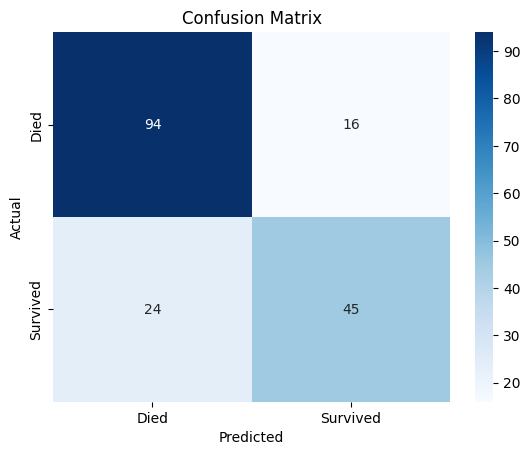

In [37]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Died", "Survived"],
    yticklabels=["Died", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82       110
           1       0.74      0.65      0.69        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.76       179
weighted avg       0.77      0.78      0.77       179



In [39]:
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.7601449275362319


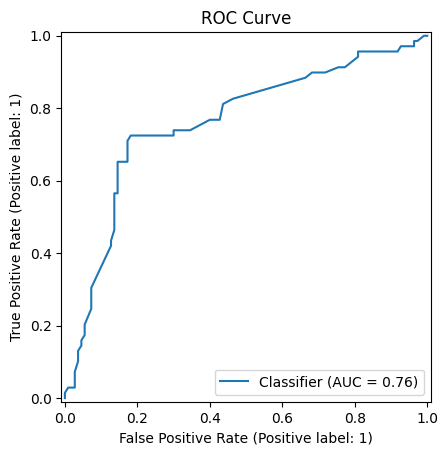

In [40]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")
plt.show()

In [41]:
lr = model.named_steps["logistic_regression"]

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

coefficients

,Feature,Coefficient
0,Sex,-1.202824
1,Age,-0.093421


Part II--Full Titanic Data Science Analysis

In [42]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [43]:
print("Train:", train.shape)
print("Test:", test.shape)

Train: (891, 12)
Test: (418, 11)


In [44]:
train["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [45]:
train["Survived"].value_counts(normalize=True) * 100

,proportion
Survived,
0,61.616162
1,38.383838


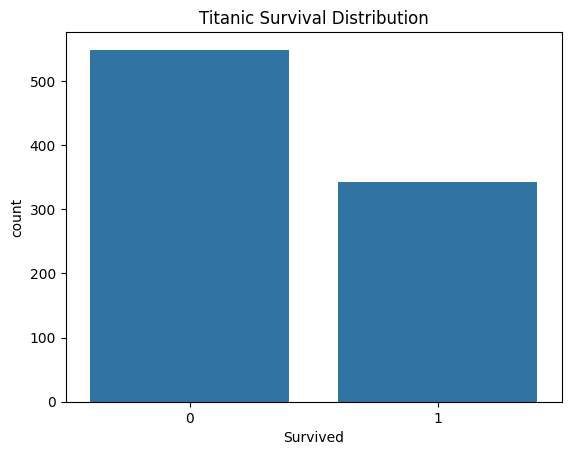

In [46]:
sns.countplot(
    data=train,
    x="Survived"
)

plt.title("Titanic Survival Distribution")
plt.show()

In [47]:
pd.crosstab(
    train["Sex"],
    train["Survived"],
    normalize="index"
)

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


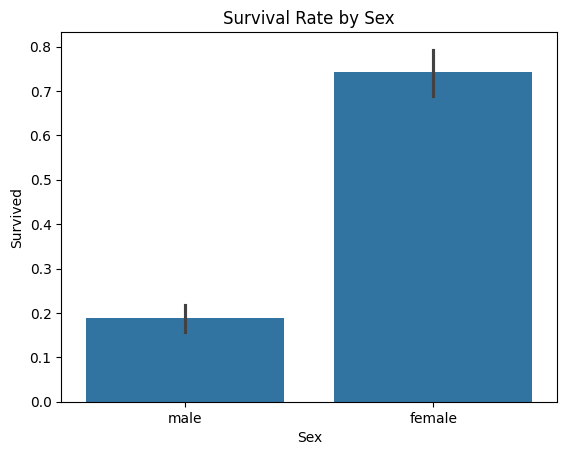

In [48]:
sns.barplot(
    data=train,
    x="Sex",
    y="Survived"
)

plt.title("Survival Rate by Sex")
plt.show()

In [49]:
pd.crosstab(
    train["Pclass"],
    train["Survived"],
    normalize="index"
)

Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


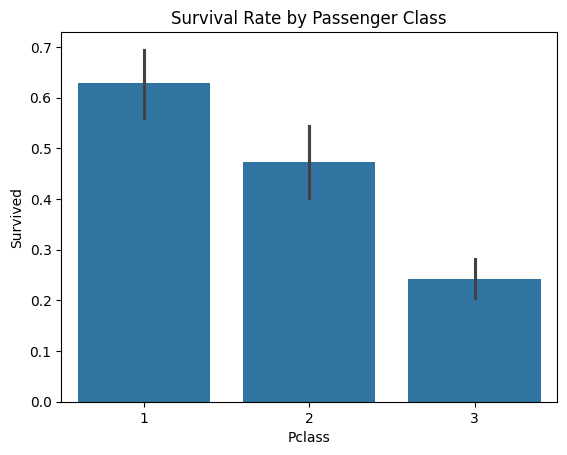

In [50]:
sns.barplot(
    data=train,
    x="Pclass",
    y="Survived"
)

plt.title("Survival Rate by Passenger Class")
plt.show()

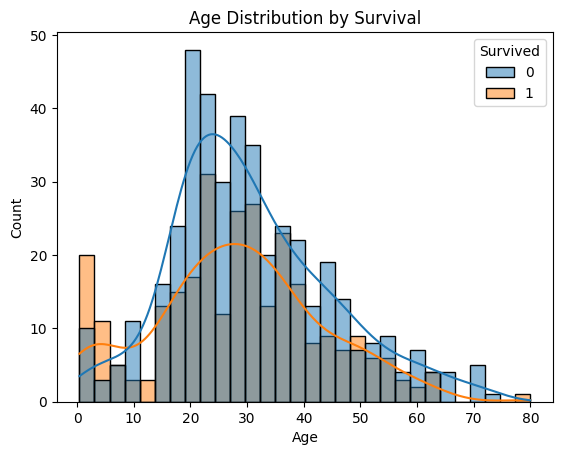

In [51]:
sns.histplot(
    data=train,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True
)

plt.title("Age Distribution by Survival")
plt.show()

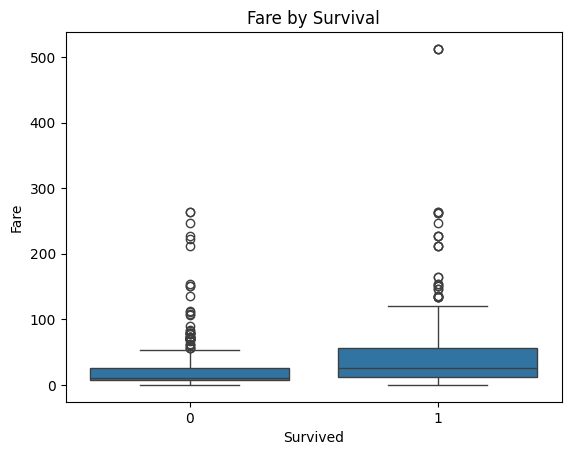

In [52]:
sns.boxplot(
    data=train,
    x="Survived",
    y="Fare"
)

plt.title("Fare by Survival")
plt.show()

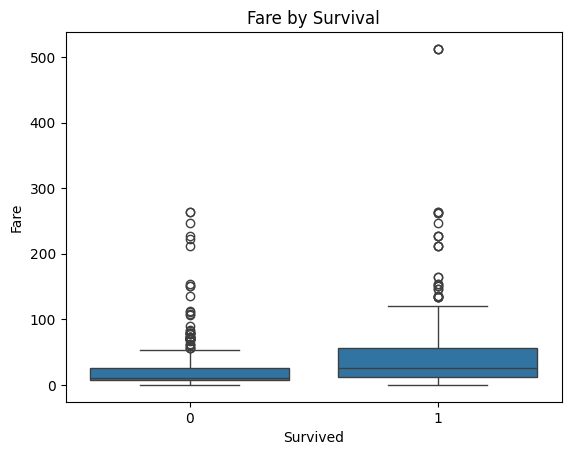

In [53]:
sns.boxplot(
    data=train,
    x="Survived",
    y="Fare"
)

plt.title("Fare by Survival")
plt.show()

In [54]:
train["Fare"].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


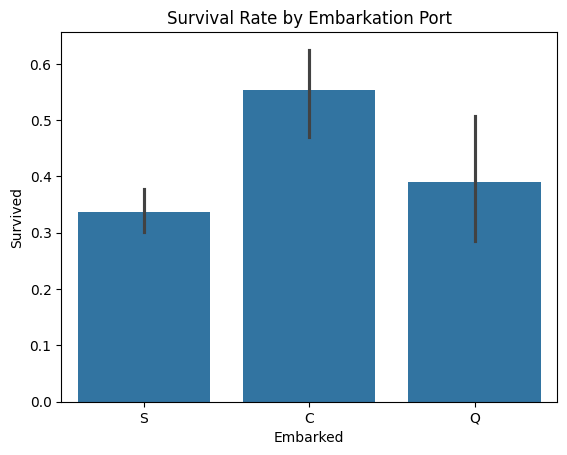

In [56]:
sns.barplot(
    data=train,
    x="Embarked",
    y="Survived"
)

plt.title("Survival Rate by Embarkation Port")
plt.show()

In [59]:
def engineer_features(df):

  df = df.copy()

# Family size
  df["FamilySize"] = (
      df["SibSp"] +
      df["Parch"] +
      1
  )

# Traveling alone
  df["IsAlone"] = (
      df["FamilySize"] == 1
  ).astype(int)

#Extract title
  df["Title"] = (
      df["Name"]
      .str.extract(r", \s*([^.]*)\.")
      [0]
      .str.strip()
  )

# Group rare titles
  common_titles = [
      "Mr",
      "Miss",
      "Mrs",
      "Master"
  ]

  df["Title"] = df["Title"].where(
      df["Title"].isin(common_titles),
      "Rare"
  )

# Cabin deck
  df["Deck"] = (
      df["Cabin"]
      .fillna("Unknown")
      .str[0]
  )

# Log transform highly skewed fare
  df["LogFare"] = np.log1p(df["Fare"])

  return df

In [ ]:
train_fe = engineer_features(train)